### Netflix Movies & TV Shows - EDA Assignment

#### Problem Statement:  
Netflix has become one of the world’s largest entertainment platforms, offering thousands of 
movies and TV shows. Understanding its content trends can help producers, marketers, and 
strategists make data-driven decisions. In this assignment, students will perform Exploratory Data 
Analysis (EDA) on Netflix’s titles dataset to uncover trends related to genres, countries, release 
years, and content ratings

#### Dataset Link:  
[Netflix Movies and TV Shows - Kaggle](https://www.kaggle.com/datasets/shivamb/netflix-shows) 

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [25]:
df = pd.read_csv('netflix_titles.csv')

In [26]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
print("Shape of the dataset:", df.shape)
print("Column names:", df.columns)
print("Info summary of the dataset:")
df.info()

Shape of the dataset: (8807, 12)
Column names: Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')
Info summary of the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)

Missing values per column:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [29]:
df_cleaned = df.dropna(subset=['title', 'type'])
print(df_cleaned.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [30]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce', infer_datetime_format=True)

C:\Users\Emad\AppData\Local\Temp\ipykernel_12272\2479896838.py:2: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce', infer_datetime_format=True)


#### EDA Questions:

• How many total movies vs TV shows are in the dataset?

• Which are the top 10 countries producing Netflix content?

• What is the most common genre on Netflix?

• Which years saw the highest number of releases?

• What is the distribution of content ratings (G, PG, PG-13, TV-MA, etc.)?

• Which directors have the most titles on

In [ ]:
total_movies = df[df['type'] == 'Movie'].shape[0]
total_tv_shows = df[df['type'] == 'TV Show'].shape[0]
print("Total Movies:", total_movies)
print("Total TV Shows:", total_tv_shows)

Total Movies: 6131
Total TV Shows: 2676


In [32]:
df_countries = df.dropna(subset=['country']).copy()
df_countries['country'] = df_countries['country'].str.split(',').apply(lambda lst: [c.strip() for c in lst])
top_countries = df_countries.explode('country')['country'].value_counts().head(10)
print("Top 10 countries with the most titles:")
print(top_countries)

Top 10 countries with the most titles:
country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


In [33]:
tv_shows = df[df['type'] == 'TV Show'].dropna(subset=['listed_in']).copy()
tv_shows['genre'] = tv_shows['listed_in'].str.split(',').apply(lambda lst: [g.strip() for g in lst])
most_common_tv_genre = tv_shows.explode('genre')['genre'].value_counts().idxmax()
print("Most common genre for TV Shows:", most_common_tv_genre)

Most common genre for TV Shows: International TV Shows
 International TV Shows


In [ ]:
year_counts = df['release_year'].value_counts()
highest_release_year = year_counts.idxmax()
highest_release_count = year_counts.max()
print(f"The year with the highest number of releases is {highest_release_year} with {highest_release_count}")

The year with the highest number of releases is 2018 with 1147


In [ ]:
rating_counts = df['rating'].dropna().value_counts()
print("Distribution of content ratings:")
print(rating_counts)

Distribution of content ratings:
rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


In [36]:
df_directors = df.dropna(subset=['director']).copy()
df_directors['director'] = df_directors['director'].str.split(',').apply(lambda lst: [d.strip() for d in lst])
top_directors = df_directors.explode('director')['director'].value_counts().head(10)
print("Top 10 directors with the most titles:")
print(top_directors)

Top 10 directors with the most titles:
director
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Marcus Raboy           16
Suhas Kadav            16
Jay Karas              15
Cathy Garcia-Molina    13
Youssef Chahine        12
Martin Scorsese        12
Jay Chapman            12
Name: count, dtype: int64


#### Visualization Questions:

• Bar chart showing Movies vs TV Shows count.

• Horizontal bar chart of Top 10 countries by content count.

• Pie chart showing content type distribution by rating.

• Line plot showing number of releases per year.

• Heatmap showing country vs genre frequency.

### Bar chart for Movies vs TV Shows



C:\Users\Emad\AppData\Local\Temp\ipykernel_12272\3683249773.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=sizes, palette=colors)


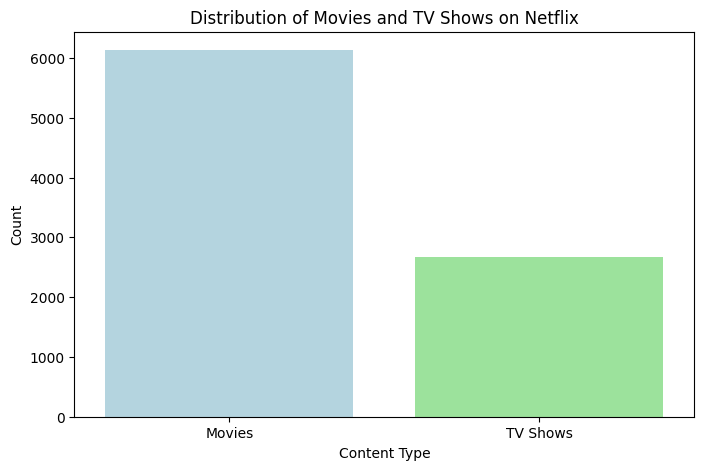

In [37]:

labels = ['Movies', 'TV Shows']
sizes = [total_movies, total_tv_shows]
colors = ['lightblue', 'lightgreen']

plt.figure(figsize=(8, 5))
plt.title('Distribution of Movies and TV Shows on Netflix')
sns.barplot(x=labels, y=sizes, palette=colors)

plt.xlabel('Content Type')
plt.ylabel('Count')
plt.show()

### Horizontal bar chart of Top 10 countries by content count.


C:\Users\Emad\AppData\Local\Temp\ipykernel_12272\2997969647.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')


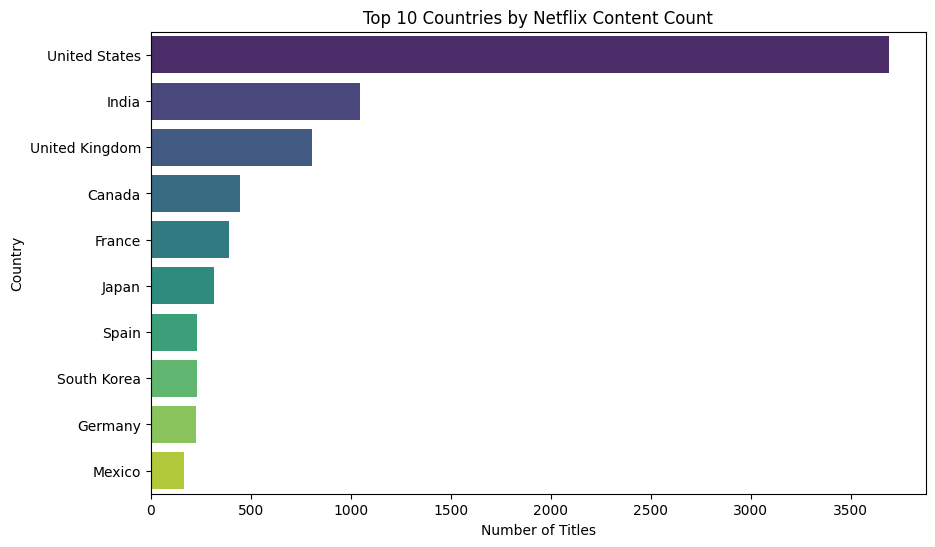

In [ ]:
df_countries = df.dropna(subset=['country']).copy()
df_countries['country'] = df_countries['country'].str.split(',').apply(lambda lst: [c.strip() for c in lst])
top_countries = df_countries.explode('country')['country'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 10 Countries by Netflix Content Count')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

### Pie chart showing content type distribution by rating.


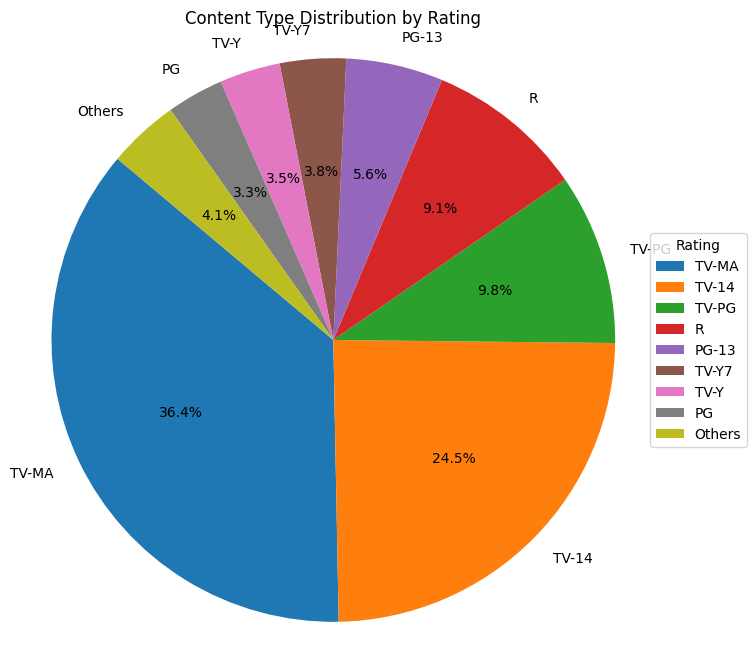

In [ ]:
rating_counts = df['rating'].fillna('Unknown').value_counts()
total = rating_counts.sum()
rel = rating_counts / total
threshold = 0.03
large = rating_counts[rel >= threshold]
small_sum = int(rating_counts[rel < threshold].sum())
labels = list(large.index)
sizes = list(large.values)
if small_sum > 0:
    labels.append('Others')
    sizes.append(small_sum)

plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Content Type Distribution by Rating')
plt.axis('equal')
plt.legend(wedges, labels, title='Rating', loc='center left', bbox_to_anchor=(1, 0, 0.5, 1))
plt.show()

### Line plot showing number of releases per year.

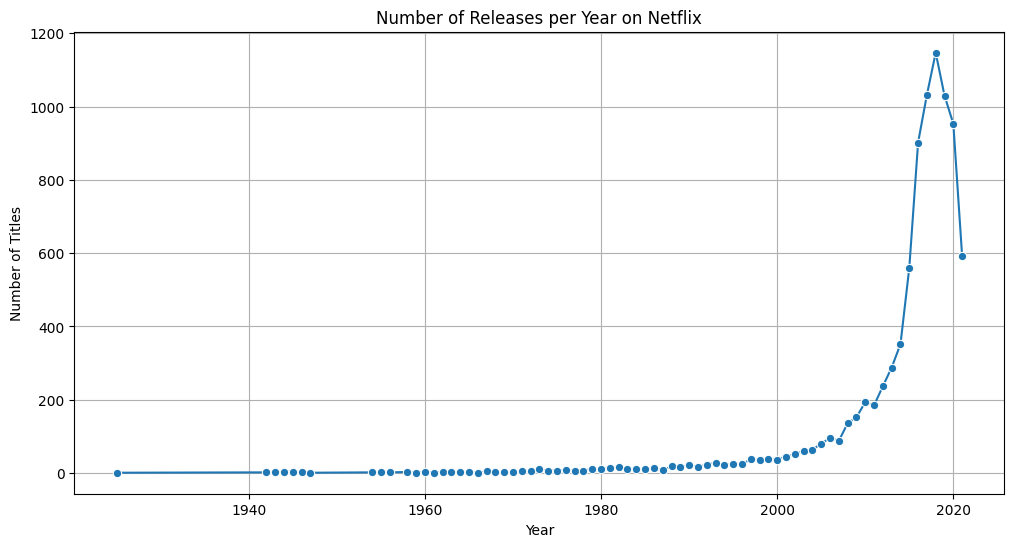

In [40]:
release_counts = df['release_year'].value_counts().sort_index()
plt.figure(figsize=(12, 6))
sns.lineplot(x=release_counts.index, y=release_counts.values, marker='o')
plt.title('Number of Releases per Year on Netflix')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.grid(True)
plt.show()

### Heatmap showing country vs genre frequency.

Most common genre on Netflix: International Movies


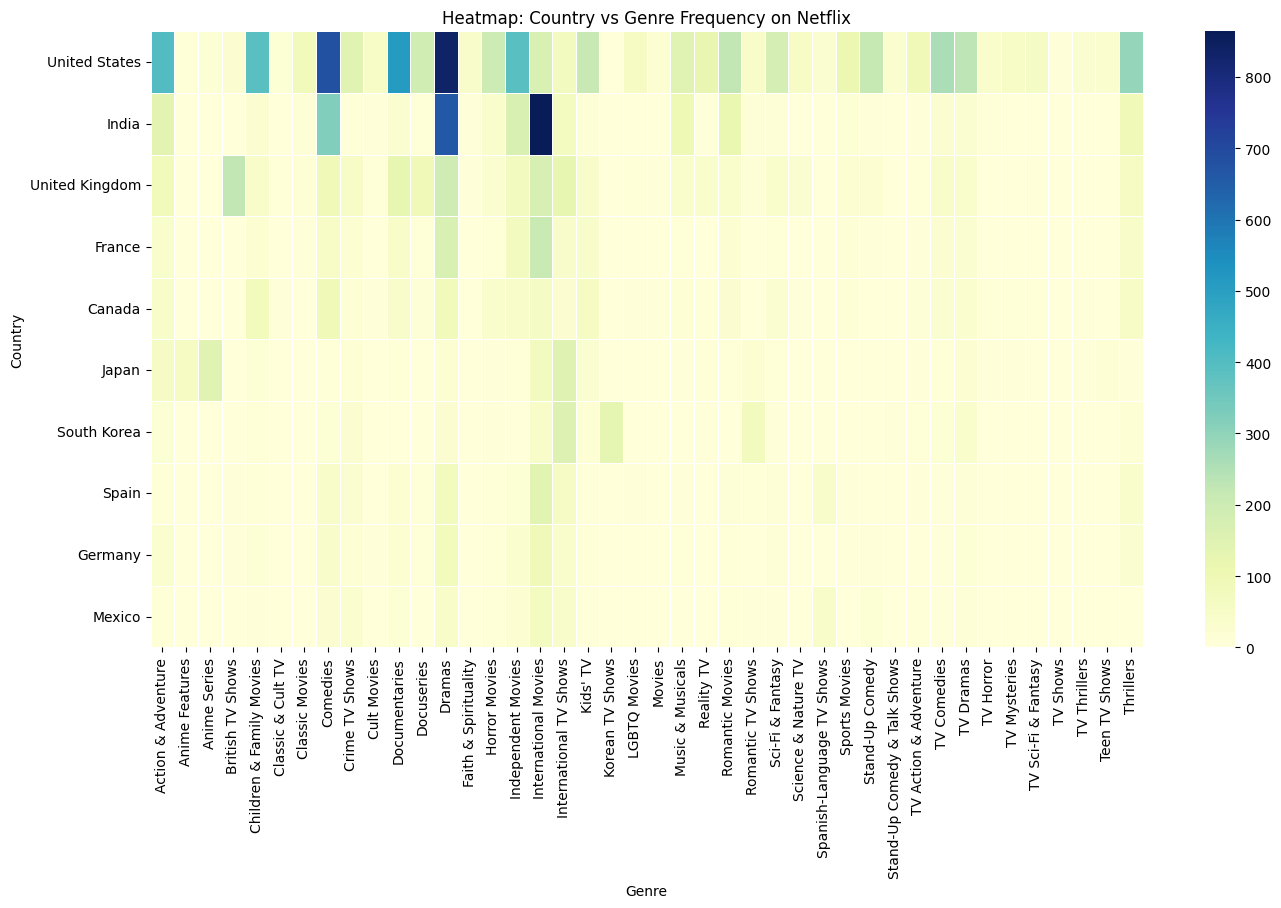

In [ ]:
df_hm = df.dropna(subset=['country', 'listed_in']).copy()
df_hm['country'] = df_hm['country'].str.split(',').apply(lambda lst: [c.strip() for c in lst])
df_hm['genre'] = df_hm['listed_in'].str.split(',').apply(lambda lst: [g.strip() for g in lst])
df_hm = df_hm.explode('country').explode('genre')
most_common_genre = df_hm['genre'].value_counts().idxmax()
print("Most common genre on Netflix:", most_common_genre)

country_genre = pd.crosstab(df_hm['country'], df_hm['genre'])
top_countries = country_genre.sum(axis=1).sort_values(ascending=False).head(10).index
country_genre_top = country_genre.loc[top_countries]

plt.figure(figsize=(16, 8))
sns.heatmap(country_genre_top, cmap='YlGnBu', linewidths=0.5)
plt.title('Heatmap: Country vs Genre Frequency on Netflix')
plt.xlabel('Genre')
plt.ylabel('Country')
plt.show()